# Регрессия глубины дефектов (вариант B) — 2 эксперимента

Чистая регрессия: бэкбон → 1 нейрон, лосс **SmoothL1 (Huber)**, таргет — глубина
залегания в **мм**. Обучаемся только на дефектных кропах (локализацию на инференсе
даёт сегментация).

**Диапазоны глубин почти не пересекаются:** kaggle = 5–25 мм (5 дискретных),
tpu = 0.5–6.1 мм (непрерывно). Отсюда два эксперимента:

1. **Перенос:** train = kaggle, test = весь tpu (held-out домен). Честная оценка
   переноса, но tpu-диапазон для модели — экстраполяция вниз.
2. **Смесь:** train = kaggle + часть tpu-видео, test = held-out видео каждого
   домена, метрики раздельно. Смешение закрывает 0.5–25 мм → экстраполяция
   превращается в интерполяцию.

Метрики: `mae_mm`, `rmse_mm`, `r2` + дискретизированные `acc_quant`/`qwk_quant`
(предсказание → ближайший узел kaggle-сетки; осмысленно в основном на kaggle).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))   # запускать из regression-experiments/notebooks
import numpy as np, torch
import matplotlib.pyplot as plt

import main as M
from config import CFG
from datasets import Modes
from metrics import RegressionMetrics

MODE = Modes.p5_d1
CFG.train.epochs = 20          # для ноутбука; в проде — 50/100
device = M.get_device()
print("device:", device, "| mode:", MODE.value, "| loss:", CFG.regression.loss_name,
      "| epochs:", CFG.train.epochs)

device: mps | mode: p5+d1 | loss: smooth_l1 | epochs: 20


In [2]:
# TSR-признаки (кэшируются один раз) + сборка индексов кропов
M.precompute_features()
M.precompute_tpu_features()

idx_kaggle = M.build_index_kaggle()
idx_tpu    = M.build_index_tpu()
print(f"кропов: kaggle={len(idx_kaggle)} | tpu={len(idx_tpu)}")
print("kaggle глубины, мм:", sorted(set(round(r[3],2) for r in idx_kaggle)))
print("tpu глубины, мм   :", sorted(set(round(r[3],2) for r in idx_tpu)))

кропов: kaggle=376 | tpu=160
kaggle глубины, мм: [5.0, 10.0, 15.0, 20.0, 25.0]
tpu глубины, мм   : [1.0, 1.5, 1.7, 1.9, 2.1, 2.2, 2.6, 3.1, 3.6, 3.8, 4.0, 4.2, 4.7, 5.2, 5.7, 5.9, 6.1]


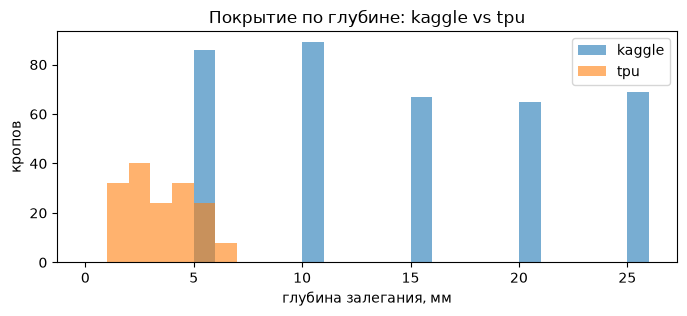

In [3]:
# Распределение таргета по доменам
fig, ax = plt.subplots(figsize=(8,3))
ax.hist([r[3] for r in idx_kaggle], bins=np.arange(0,27,1), alpha=.6, label="kaggle")
ax.hist([r[3] for r in idx_tpu],    bins=np.arange(0,27,1), alpha=.6, label="tpu")
ax.set_xlabel("глубина залегания, мм"); ax.set_ylabel("кропов"); ax.legend()
ax.set_title("Покрытие по глубине: kaggle vs tpu"); plt.show()

## Эксперимент 1 — перенос kaggle → tpu

Обучаем на всём kaggle, тестируем на всём tpu. Ожидаем заметную ошибку: tpu-глубины
(0.5–6 мм) лежат ниже kaggle-сетки (5–25 мм) — модель экстраполирует.

In [4]:
out1 = M.run(idx_kaggle, idx_tpu, mode=MODE, tag="exp1_kaggle2tpu", device=device)
metrics1 = out1["metrics"].by_domain()
metrics1

Current model: convnext_nano (pretrained=False)


Current model: RegressionModel (device=mps)
START tag=exp1_kaggle2tpu device=mps epochs=20 lr=0.001 params=14963441


epoch   1/20 | train_loss 1.67637 | val_mae 11.3935 мм | val_rmse 12.1410 мм


epoch   2/20 | train_loss 0.47569 | val_mae 11.7434 мм | val_rmse 12.0867 мм


epoch   3/20 | train_loss 0.43261 | val_mae 11.1665 мм | val_rmse 11.6177 мм


...

epoch  17/20 | train_loss 0.06339 | val_mae 13.9678 мм | val_rmse 14.9793 мм


epoch  18/20 | train_loss 0.05976 | val_mae 14.9511 мм | val_rmse 16.3313 мм


epoch  19/20 | train_loss 0.05108 | val_mae 13.8140 мм | val_rmse 15.0378 мм


epoch  20/20 | train_loss 0.04752 | val_mae 14.5847 мм | val_rmse 15.8117 мм
FINAL mae=14.5847 мм rmse=15.8117 мм
DONE tag=exp1_kaggle2tpu params=14963441 → /Users/tomatocoder/Documents/thermal-control-ya-project/runs/20260817_165511_exp1_kaggle2tpu

=== RegressionMetrics (по доменам) ===
[tpu   ] mae_mm=14.5847 | rmse_mm=15.8117 | medae_mm=13.6262 | bias_mm=14.5847 | r2=-104.6108 | acc_quant=0.0000 | qwk_quant=0.0000
[all   ] mae_mm=14.5847 | rmse_mm=15.8117 | medae_mm=13.6262 | bias_mm=14.5847 | r2=-104.6108 | acc_quant=0.0000 | qwk_quant=0.0000


{'tpu': {'mae_mm': 14.584666752815247,
  'rmse_mm': 15.811698853076265,
  'medae_mm': 13.626196384429932,
  'bias_mm': 14.584666752815247,
  'r2': -104.6108064160141,
  'acc_quant': 0.0,
  'qwk_quant': 0.0},
 'all': {'mae_mm': 14.584666752815247,
  'rmse_mm': 15.811698853076265,
  'medae_mm': 13.626196384429932,
  'bias_mm': 14.584666752815247,
  'r2': -104.6108064160141,
  'acc_quant': 0.0,
  'qwk_quant': 0.0}}

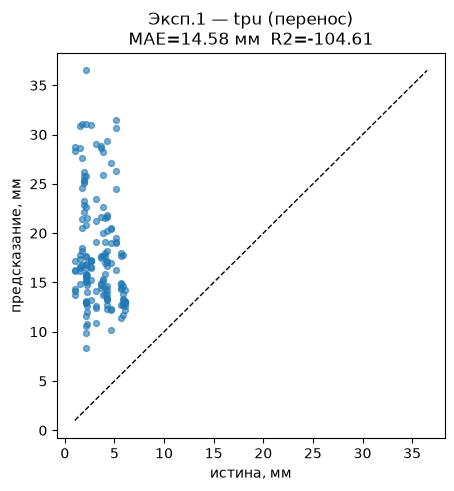

In [5]:
# pred vs true на tpu
def scatter_pred(rm, title):
    yt, yp = rm.y_true, rm.y_pred
    lo, hi = min(yt.min(), yp.min()), max(yt.max(), yp.max())
    fig, ax = plt.subplots(figsize=(5,5))
    ax.scatter(yt, yp, s=18, alpha=.6)
    ax.plot([lo,hi],[lo,hi],"k--",lw=1)
    ax.set_xlabel("истина, мм"); ax.set_ylabel("предсказание, мм")
    m = rm.compute(); ax.set_title(f"{title}\nMAE={m['mae_mm']:.2f} мм  R2={m['r2']:.2f}")
    plt.show()

scatter_pred(out1["metrics"], "Эксп.1 — tpu (перенос)")

## Эксперимент 2 — смешанный трейн, раздельный тест

`train = kaggle + часть tpu-видео`, `test = held-out видео каждого домена`. Сплит
строго по видео (у tpu все дефекты одного видео на одной глубине → случайный сплит
= утечка). Метрики считаем раздельно по доменам.

In [6]:
combined = idx_kaggle + idx_tpu
# по 3 held-out видео из каждого домена в тест, остальное — в общий трейн
train_idx, test_idx = M.split_by_video(combined, n_test=3,
                                       domains=["kaggle","tpu"], seed=CFG.train.seed)
def dom_vids(idx, d): return sorted({r[0] for r in idx if r[4]==d})
print("train видео: kaggle=%d tpu=%d" % (len(dom_vids(train_idx,'kaggle')), len(dom_vids(train_idx,'tpu'))))
print("test  видео: kaggle=%d tpu=%d" % (len(dom_vids(test_idx,'kaggle')), len(dom_vids(test_idx,'tpu'))))
print("train кропов=%d test кропов=%d" % (len(train_idx), len(test_idx)))

train видео: kaggle=35 tpu=17
test  видео: kaggle=3 tpu=3
train кропов=492 test кропов=44


In [7]:
out2 = M.run(train_idx, test_idx, mode=MODE, tag="exp2_mixed", device=device)
metrics2 = out2["metrics"].by_domain()
metrics2

Current model: convnext_nano (pretrained=False)


Current model: RegressionModel (device=mps)
START tag=exp2_mixed device=mps epochs=20 lr=0.001 params=14963441


epoch   1/20 | train_loss 1.94553 | val_mae 7.4867 мм | val_rmse 8.9006 мм


epoch   2/20 | train_loss 0.46248 | val_mae 5.8312 мм | val_rmse 6.9583 мм


epoch   3/20 | train_loss 0.45047 | val_mae 5.5463 мм | val_rmse 6.4179 мм


...

epoch  17/20 | train_loss 0.28965 | val_mae 5.4471 мм | val_rmse 6.8929 мм


epoch  18/20 | train_loss 0.24058 | val_mae 5.5564 мм | val_rmse 6.8839 мм


epoch  19/20 | train_loss 0.23769 | val_mae 4.3002 мм | val_rmse 5.9579 мм


epoch  20/20 | train_loss 0.15246 | val_mae 3.4385 мм | val_rmse 4.3370 мм
FINAL mae=3.4385 мм rmse=4.3370 мм
DONE tag=exp2_mixed params=14963441 → /Users/tomatocoder/Documents/thermal-control-ya-project/runs/20260817_165525_exp2_mixed

=== RegressionMetrics (по доменам) ===
[kaggle] mae_mm=4.5058 | rmse_mm=5.5186 | medae_mm=4.6370 | bias_mm=3.7554 | r2=0.3185 | acc_quant=0.3500 | qwk_quant=0.6377
[tpu   ] mae_mm=2.5491 | rmse_mm=3.0175 | medae_mm=1.8829 | bias_mm=2.4819 | r2=-2.7834 | acc_quant=0.9167 | qwk_quant=0.0000
[all   ] mae_mm=3.4385 | rmse_mm=4.3370 | medae_mm=2.2288 | bias_mm=3.0608 | r2=0.5062 | acc_quant=0.6591 | qwk_quant=0.7810


{'kaggle': {'mae_mm': 4.505779814720154,
  'rmse_mm': 5.51859069389712,
  'medae_mm': 4.637018442153931,
  'bias_mm': 3.7554048776626585,
  'r2': 0.31849298189410524,
  'acc_quant': 0.35,
  'qwk_quant': 0.6376811594202898},
 'tpu': {'mae_mm': 2.5491495927174888,
  'rmse_mm': 3.0175011848371853,
  'medae_mm': 1.8828892707824707,
  'bias_mm': 2.481891393661499,
  'r2': -2.7833705393989163,
  'acc_quant': 0.9166666666666666,
  'qwk_quant': 0.0},
 'all': {'mae_mm': 3.4385269663550635,
  'rmse_mm': 4.337008778962779,
  'medae_mm': 2.2288262844085693,
  'bias_mm': 3.0607611591165718,
  'r2': 0.5062257734257567,
  'acc_quant': 0.6590909090909091,
  'qwk_quant': 0.7809734513274337}}

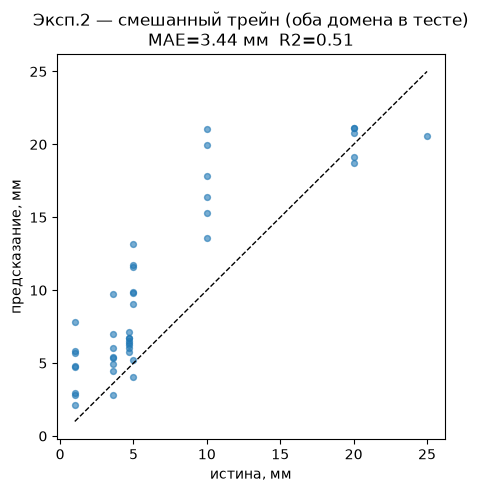

In [8]:
scatter_pred(out2["metrics"], "Эксп.2 — смешанный трейн (оба домена в тесте)")

### (опц.) k-fold по tpu-видео

tpu-видео мало (~20), одиночный held-out из 3 видео = шумная оценка. Ниже —
короткий k-fold: каждый фолд держит часть tpu-видео в тесте, kaggle всегда в трейне
целиком, tpu-train = остальные tpu-видео. Метрику берём по tpu-части теста.

In [9]:
from collections import defaultdict
tpu_vids = sorted({r[0] for r in idx_tpu})
rng = np.random.default_rng(CFG.train.seed)
tpu_vids = list(rng.permutation(tpu_vids))
K = 4
folds = [tpu_vids[i::K] for i in range(K)]

fold_mae = []
for fi, hold in enumerate(folds, 1):
    hold = set(hold)
    tpu_tr = [r for r in idx_tpu if r[0] not in hold]
    tpu_te = [r for r in idx_tpu if r[0] in hold]
    tr = idx_kaggle + tpu_tr
    res = M.run(tr, tpu_te, mode=MODE, tag=f"exp2_kfold{fi}", device=device)
    m = res["metrics"].compute()
    fold_mae.append(m["mae_mm"])
    print(f"fold {fi}: hold tpu-видео={len(hold)} | tpu MAE={m['mae_mm']:.2f} мм  R2={m['r2']:.2f}")

print(f"\nk-fold tpu MAE: {np.mean(fold_mae):.2f} ± {np.std(fold_mae):.2f} мм")

Current model: convnext_nano (pretrained=False)


Current model: RegressionModel (device=mps)
START tag=exp2_kfold1 device=mps epochs=20 lr=0.001 params=14963441


epoch   1/20 | train_loss 1.67036 | val_mae 8.5507 мм | val_rmse 10.5921 мм


epoch   2/20 | train_loss 0.50330 | val_mae 4.9283 мм | val_rmse 5.9144 мм


epoch   3/20 | train_loss 0.41784 | val_mae 6.2142 мм | val_rmse 7.1362 мм


...

epoch  17/20 | train_loss 0.04635 | val_mae 1.4197 мм | val_rmse 2.4346 мм


epoch  18/20 | train_loss 0.05015 | val_mae 2.5514 мм | val_rmse 3.0646 мм


epoch  19/20 | train_loss 0.04309 | val_mae 1.5439 мм | val_rmse 2.2054 мм


epoch  20/20 | train_loss 0.03743 | val_mae 1.9681 мм | val_rmse 2.2600 мм
FINAL mae=1.9681 мм rmse=2.2600 мм
DONE tag=exp2_kfold4 params=14963441 → /Users/tomatocoder/Documents/thermal-control-ya-project/runs/20260817_165628_exp2_kfold4

=== RegressionMetrics (по доменам) ===
[tpu   ] mae_mm=1.9681 | rmse_mm=2.2600 | medae_mm=1.8153 | bias_mm=-0.4083 | r2=-5.0922 | acc_quant=1.0000 | qwk_quant=nan
[all   ] mae_mm=1.9681 | rmse_mm=2.2600 | medae_mm=1.8153 | bias_mm=-0.4083 | r2=-5.0922 | acc_quant=1.0000 | qwk_quant=nan
fold 4: hold tpu-видео=5 | tpu MAE=1.97 мм  R2=-5.09

k-fold tpu MAE: 1.95 ± 0.16 мм


/Users/tomatocoder/Documents/thermal-control-ya-project/.venv/lib/python3.12/site-packages/sklearn/utils/_param_validation.py:218: UndefinedMetricWarning: `y1`, `y2` and `labels` have only one label in common. `cohen_kappa_score` is undefined and set to the value defined by the the `replace_undefined_by` param, which is set to nan.
  return func(*args, **kwargs)
/Users/tomatocoder/Documents/thermal-control-ya-project/.venv/lib/python3.12/site-packages/sklearn/utils/_param_validation.py:218: UndefinedMetricWarning: `y1`, `y2` and `labels` have only one label in common. `cohen_kappa_score` is undefined and set to the value defined by the the `replace_undefined_by` param, which is set to nan.
  return func(*args, **kwargs)
/Users/tomatocoder/Documents/thermal-control-ya-project/.venv/lib/python3.12/site-packages/sklearn/utils/_param_validation.py:218: UndefinedMetricWarning: `y1`, `y2` and `labels` have only one label in common. `cohen_kappa_score` is undefined and set to the value define

## Оптимизатор: Adam vs Muon

Muon применяется к 2D+ скрытым весам (свёртки решейпятся к 2D), Adam — к
bias/нормам/голове. Сравним на сетапе Эксп.2 (смешанный трейн). Переключение —
через `CFG.optim.name`.

In [10]:
cmp = {}
for opt in ["adam", "muon"]:
    CFG.optim.name = opt
    res = M.run(train_idx, test_idx, mode=MODE, tag=f"opt_{opt}", device=device)
    cmp[opt] = res["metrics"].by_domain()
CFG.optim.name = "adam"   # вернуть дефолт

import pandas as pd
rows = [{"optim": o, "domain": d, **{k:round(v,3) for k,v in m.items()}}
        for o, dd in cmp.items() for d, m in dd.items()]
pd.DataFrame(rows).set_index(["optim","domain"])[["mae_mm","rmse_mm","r2"]]

Current model: convnext_nano (pretrained=False)


Current model: RegressionModel (device=mps)
START tag=opt_adam device=mps epochs=20 lr=0.001 params=14963441


epoch   1/20 | train_loss 1.94553 | val_mae 7.4867 мм | val_rmse 8.9006 мм


epoch   2/20 | train_loss 0.46248 | val_mae 5.8312 мм | val_rmse 6.9583 мм


epoch   3/20 | train_loss 0.45047 | val_mae 5.5463 мм | val_rmse 6.4179 мм


...

epoch  17/20 | train_loss 0.00806 | val_mae 1.3024 мм | val_rmse 1.6424 мм


epoch  18/20 | train_loss 0.00690 | val_mae 1.5551 мм | val_rmse 1.9049 мм


epoch  19/20 | train_loss 0.00592 | val_mae 1.4186 мм | val_rmse 1.7003 мм


epoch  20/20 | train_loss 0.00616 | val_mae 1.4826 мм | val_rmse 1.7778 мм
FINAL mae=1.4826 мм rmse=1.7779 мм
DONE tag=opt_muon params=14963441 → /Users/tomatocoder/Documents/thermal-control-ya-project/runs/20260817_165702_opt_muon

=== RegressionMetrics (по доменам) ===
[kaggle] mae_mm=1.1842 | rmse_mm=1.5365 | medae_mm=0.7359 | bias_mm=0.0002 | r2=0.9472 | acc_quant=0.8500 | qwk_quant=0.9524
[tpu   ] mae_mm=1.7312 | rmse_mm=1.9564 | medae_mm=1.6214 | bias_mm=0.6712 | r2=-0.5904 | acc_quant=0.9167 | qwk_quant=0.0000
[all   ] mae_mm=1.4826 | rmse_mm=1.7779 | medae_mm=1.3847 | bias_mm=0.3662 | r2=0.9170 | acc_quant=0.8864 | qwk_quant=0.9476


mae_mm  rmse_mm     r2
optim domain                        
adam  kaggle   4.506    5.519  0.318
      tpu      2.549    3.018 -2.783
      all      3.439    4.337  0.506
muon  kaggle   1.184    1.536  0.947
      tpu      1.731    1.956 -0.590
      all      1.483    1.778  0.917

## Экспериментальная сетка (Muon)

`{convnext_nano, resnet34} × {p5, p5+d1} × {30, 50 эпох}` — 8 конфигураций,
оптимизатор только **Muon**. Сетап — смешанный трейн Эксп.2 (`train_idx`/`test_idx`),
метрики раздельно по доменам. Тяжёлый прогон: 8 обучений timm-сетей.

In [11]:
import pandas as pd, itertools
CFG.optim.name = "muon"

grid = list(itertools.product(
    ["resnet34"],
    # ["convnext_nano", "resnet34"],      # модель
    [Modes.p5, Modes.p5_d1, Modes.p5_d1_d2],            # каналы
    [25, 45, 60],                          # эпох
))

grid_rows, grid_metrics = [], {}
for model_name, mode, ep in grid:
    CFG.model.name = model_name
    CFG.train.epochs = ep
    key = f"{model_name}|{mode.value}|{ep}ep"
    print(f"\n########## {key} ##########")
    res = M.run(train_idx, test_idx, mode=mode, tag=f"grid_{key}", device=device)
    grid_metrics[key] = res["metrics"]
    for dom, m in res["metrics"].by_domain().items():
        grid_rows.append({"model": model_name, "mode": mode.value, "epochs": ep,
                          "domain": dom, **{k: round(v, 3) for k, v in m.items()}})

grid_df = pd.DataFrame(grid_rows)


########## resnet34|p5|25ep ##########
Current model: resnet34 (pretrained=False)


Current model: RegressionModel (device=mps)
[muon] params: muon-группа=21277056 adam-группа=17537
START tag=grid_resnet34|p5|25ep device=mps epochs=25 lr=0.001 params=21294593


epoch   1/25 | train_loss 0.36434 | val_mae 6.6345 мм | val_rmse 7.0069 мм


epoch   2/25 | train_loss 0.26962 | val_mae 5.7644 мм | val_rmse 6.1463 мм


epoch   3/25 | train_loss 0.23677 | val_mae 5.3820 мм | val_rmse 5.8609 мм


...

epoch  57/60 | train_loss 0.00887 | val_mae 0.9553 мм | val_rmse 1.3934 мм


epoch  58/60 | train_loss 0.00690 | val_mae 0.9057 мм | val_rmse 1.2990 мм


epoch  59/60 | train_loss 0.00742 | val_mae 0.9107 мм | val_rmse 1.4729 мм


epoch  60/60 | train_loss 0.00622 | val_mae 0.8507 мм | val_rmse 1.3363 мм
FINAL mae=0.8507 мм rmse=1.3363 мм
DONE tag=grid_resnet34|p5+d1+d2|60ep params=21322817 → /Users/tomatocoder/Documents/thermal-control-ya-project/runs/20260817_170643_grid_resnet34_p5+d1+d2_60ep

=== RegressionMetrics (по доменам) ===
[kaggle] mae_mm=0.7802 | rmse_mm=1.4916 | medae_mm=0.3806 | bias_mm=-0.6080 | r2=0.9502 | acc_quant=0.9500 | qwk_quant=0.9851
[tpu   ] mae_mm=0.9095 | rmse_mm=1.1916 | medae_mm=0.7466 | bias_mm=0.6037 | r2=0.4100 | acc_quant=1.0000 | qwk_quant=nan
[all   ] mae_mm=0.8507 | rmse_mm=1.3363 | medae_mm=0.4835 | bias_mm=0.0529 | r2=0.9531 | acc_quant=0.9773 | qwk_quant=0.9900


/Users/tomatocoder/Documents/thermal-control-ya-project/.venv/lib/python3.12/site-packages/sklearn/utils/_param_validation.py:218: UndefinedMetricWarning: `y1`, `y2` and `labels` have only one label in common. `cohen_kappa_score` is undefined and set to the value defined by the the `replace_undefined_by` param, which is set to nan.
  return func(*args, **kwargs)
/Users/tomatocoder/Documents/thermal-control-ya-project/.venv/lib/python3.12/site-packages/sklearn/utils/_param_validation.py:218: UndefinedMetricWarning: `y1`, `y2` and `labels` have only one label in common. `cohen_kappa_score` is undefined and set to the value defined by the the `replace_undefined_by` param, which is set to nan.
  return func(*args, **kwargs)


In [12]:
# сводка: по конфигу и домену (ключевые метрики)
tbl = (grid_df.set_index(["model","mode","epochs","domain"])
              [["mae_mm","rmse_mm","r2"]])
tbl

mae_mm  rmse_mm     r2
model    mode     epochs domain                        
resnet34 p5       25     kaggle   1.111    1.853  0.923
                         tpu      1.066    1.572 -0.027
                         all      1.086    1.706  0.924
                  45     kaggle   1.231    1.906  0.919
                         tpu      0.833    1.001  0.584
                         all      1.014    1.482  0.942
                  60     kaggle   0.705    1.598  0.943
                         tpu      0.979    1.171  0.431
                         all      0.855    1.381  0.950
         p5+d1    25     kaggle   1.618    2.376  0.874
                         tpu      0.941    1.195  0.407
                         all      1.249    1.829  0.912
                  45     kaggle   0.914    1.973  0.913
                         tpu      0.790    1.049  0.543
                         all      0.846    1.539  0.938
                  60     kaggle   0.987    1.647  0.939
                         tpu      1.228    1.558 -0.009
                         all      1.118    1.599  0.933
         p5+d1+d2 25     kaggle   1.238    1.770  0.930
                         tpu      1.258    1.546  0.007
                         all      1.249    1.651  0.928
                  45     kaggle   0.964    2.036  0.907
                         tpu      0.865    1.151  0.450
                         all      0.910    1.614  0.932
                  60     kaggle   0.780    1.492  0.950
                         tpu      0.909    1.192  0.410
                         all      0.851    1.336  0.953

In [13]:
# лучшие по tpu MAE (основная метрика на непокрытом диапазоне)
(grid_df[grid_df.domain=="tpu"]
   .sort_values("mae_mm")[["model","mode","epochs","mae_mm","rmse_mm"]]
   .reset_index(drop=True))

,model,mode,epochs,mae_mm,rmse_mm
0,resnet34,p5+d1,45,0.790,1.049
1,resnet34,p5,45,0.833,1.001
2,resnet34,p5+d1+d2,45,0.865,1.151
3,resnet34,p5+d1+d2,60,0.909,1.192
4,resnet34,p5+d1,25,0.941,1.195
5,resnet34,p5,60,0.979,1.171
6,resnet34,p5,25,1.066,1.572
7,resnet34,p5+d1,60,1.228,1.558
8,resnet34,p5+d1+d2,25,1.258,1.546


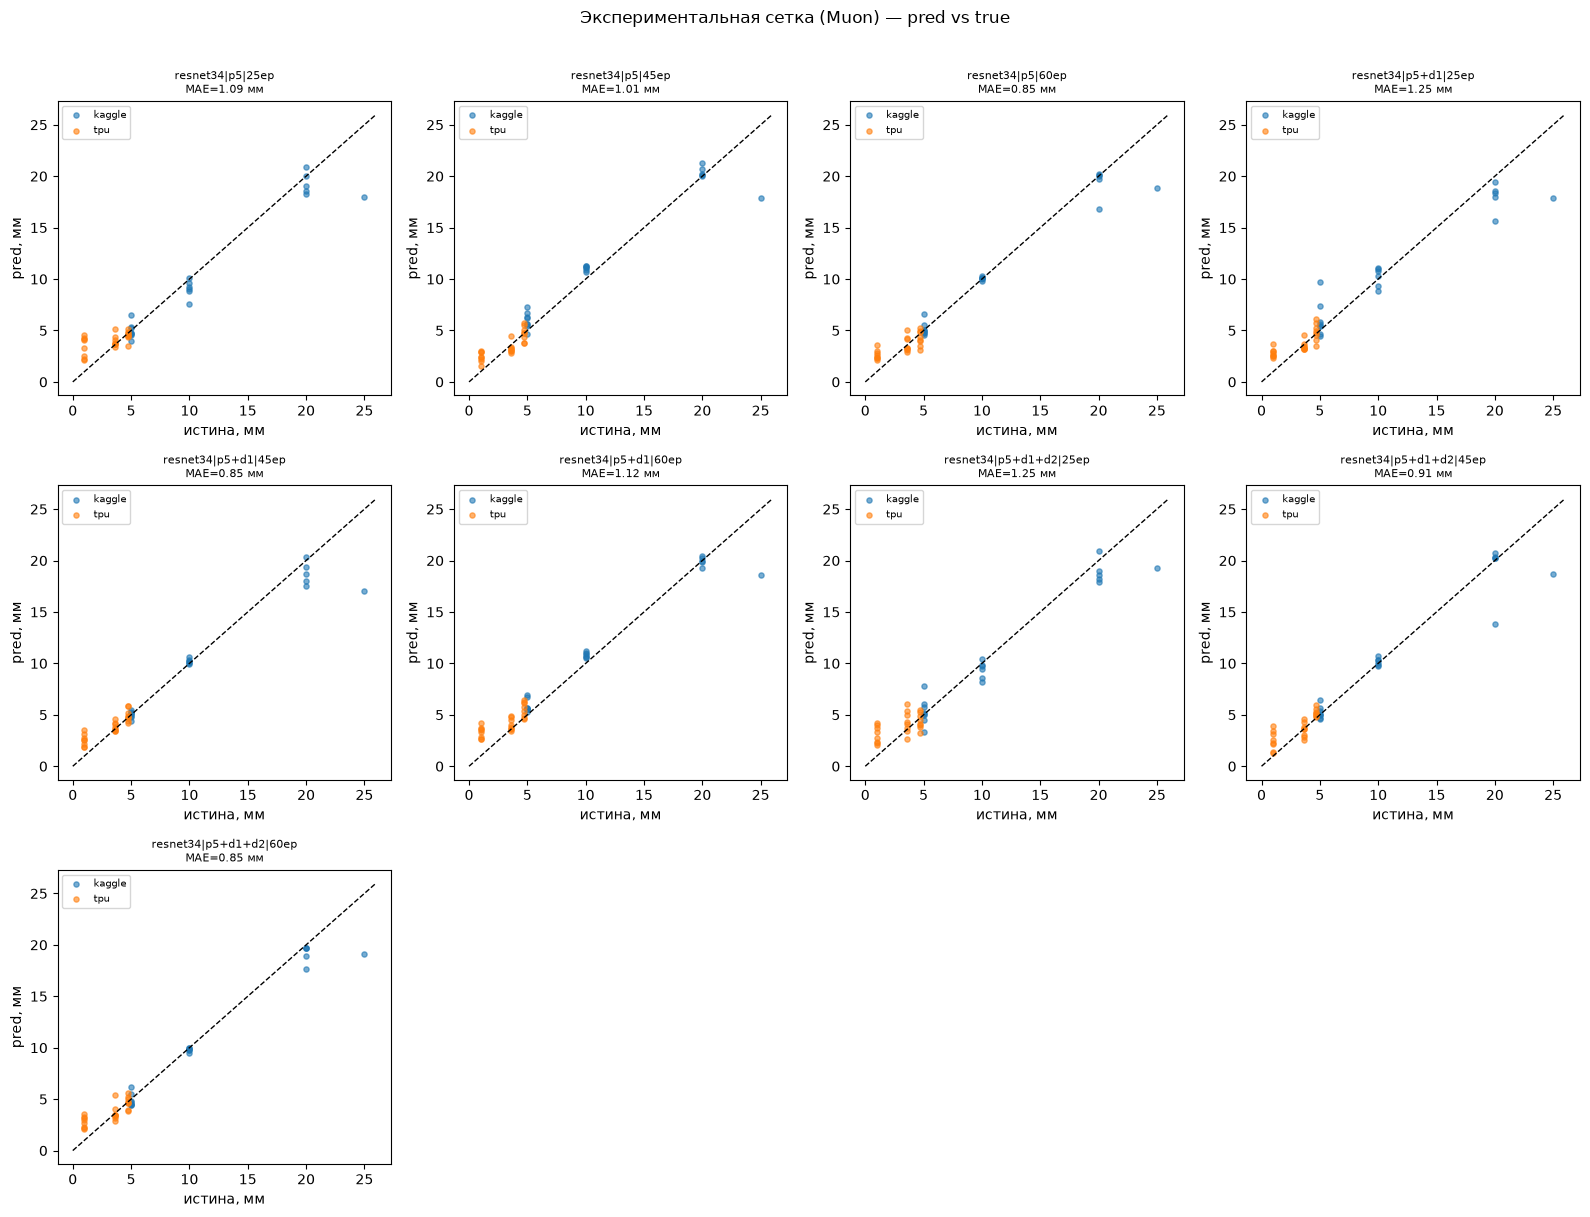

In [14]:
# pred/true по всем 8 конфигурациям
n = len(grid_metrics); ncol = 4; nrow = (n + ncol - 1)//ncol
fig, axs = plt.subplots(nrow, ncol, figsize=(4*ncol, 4*nrow))
axs = np.atleast_1d(axs).ravel()
colors = {"kaggle": "tab:blue", "tpu": "tab:orange"}
for ax, (key, rm) in zip(axs, grid_metrics.items()):
    dom = np.array([r[4] for r in test_idx])
    for d in ["kaggle","tpu"]:
        mmask = dom==d
        ax.scatter(rm.y_true[mmask], rm.y_pred[mmask], s=14, alpha=.6,
                   color=colors[d], label=d)
    lo, hi = 0, max(rm.y_true.max(), rm.y_pred.max())+1
    ax.plot([lo,hi],[lo,hi],"k--",lw=1)
    mm = rm.compute()
    ax.set_title(f"{key}\nMAE={mm['mae_mm']:.2f} мм", fontsize=8)
    ax.set_xlabel("истина, мм"); ax.set_ylabel("pred, мм")
    ax.legend(fontsize=7)
for ax in axs[n:]:
    ax.axis("off")
fig.suptitle("Экспериментальная сетка (Muon) — pred vs true", y=1.01)
plt.tight_layout(); plt.show()

## Выводы

- **Эксп.1 (перенос):** MAE на tpu отражает экстраполяцию вниз по шкале — базовая
  оценка «в лоб», без tpu в трейне.
- **Эксп.2 (смесь):** добавление tpu-видео в трейн закрывает диапазон 0.5–25 мм;
  сравни tpu-MAE с Эксп.1 — падение = выигрыш от покрытия. kaggle-MAE показывает,
  что смешение не ломает «глубокую» зону.
- **Раздельные метрики** не дают домену с бо́льшим числом кропов задавить второй.
- k-fold по tpu даёт устойчивую оценку (±) вместо одиночного шумного теста.

Дальше: вариант C (μ,σ) для доверия на инференсе; подмена GT-маски на маску от
модели сегментации при разборе сырого видео.

## Оценённые глубины на тесте

Предсказания модели Эксп.2 (`out2`) по каждому тестовому кропу и агрегировано по
видео (у tpu все дефекты видео на одной глубине → сравниваем среднее предсказание
с истиной).

In [15]:
import pandas as pd
rm = out2["metrics"]                       # y_true/y_pred в порядке test_idx (shuffle=False)
df = pd.DataFrame({
    "vid":      [r[0] for r in test_idx],
    "domain":   [r[4] for r in test_idx],
    "true_mm":  np.round(rm.y_true, 2),
    "pred_mm":  np.round(rm.y_pred, 2),
})
df["err_mm"] = np.round(df.pred_mm - df.true_mm, 2)
print("=== по кропам ===")
df

=== по кропам ===


,vid,domain,true_mm,pred_mm,err_mm
0,R_020,kaggle,5.0,4.03,-0.97
1,R_020,kaggle,10.0,16.42,6.42
2,R_020,kaggle,10.0,13.55,3.55
3,R_020,kaggle,20.0,18.75,-1.25
4,R_020,kaggle,20.0,21.12,1.12
5,R_020,kaggle,20.0,19.15,-0.85
6,Z_004,kaggle,5.0,13.14,8.14
7,Z_004,kaggle,5.0,11.75,6.75
8,Z_004,kaggle,5.0,9.07,4.07
9,Z_004,kaggle,5.0,9.88,4.88


In [16]:
# агрегировано по видео: истина, среднее предсказание, разброс, ошибка
g = (df.groupby(["domain","vid"])
       .agg(true_mm=("true_mm","first"),
            pred_mm_mean=("pred_mm","mean"),
            pred_mm_std=("pred_mm","std"),
            n=("pred_mm","size"))
       .reset_index())
g["pred_mm_mean"] = g.pred_mm_mean.round(2)
g["pred_mm_std"]  = g.pred_mm_std.round(2)
g["err_mm"]       = (g.pred_mm_mean - g.true_mm).round(2)
print("=== по видео (агрегировано) ===")
g.sort_values(["domain","true_mm"])

=== по видео (агрегировано) ===


,domain,vid,true_mm,pred_mm_mean,pred_mm_std,n,err_mm
0,kaggle,R_020,5.0,15.50,6.19,6,10.50
1,kaggle,Z_004,5.0,15.55,5.05,12,10.55
2,kaggle,Z_011,5.0,10.24,7.13,2,5.24
3,tpu,Sample_3_Static,1.0,4.58,1.90,8,3.58
4,tpu,Sample_4_Static,3.6,5.72,2.04,8,2.12
5,tpu,Sample_8_Static,4.7,6.44,0.43,8,1.74


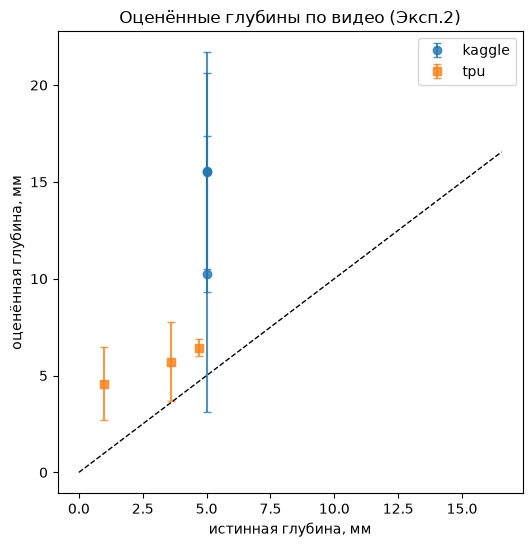

In [17]:
# истина vs предсказание по видео
fig, ax = plt.subplots(figsize=(6,6))
for d, mk in [("kaggle","o"), ("tpu","s")]:
    s = g[g.domain==d]
    ax.errorbar(s.true_mm, s.pred_mm_mean, yerr=s.pred_mm_std, fmt=mk,
                capsize=3, label=d, alpha=.8)
lo, hi = 0, max(g.true_mm.max(), g.pred_mm_mean.max())+1
ax.plot([lo,hi],[lo,hi],"k--",lw=1)
ax.set_xlabel("истинная глубина, мм"); ax.set_ylabel("оценённая глубина, мм")
ax.set_title("Оценённые глубины по видео (Эксп.2)"); ax.legend(); plt.show()

## Сетка по типу признаков: Fourier vs p5 vs p5+d1

Сравниваем регрессию глубины на трёх наборах признаков при **одинаковом**
сплите/сидах/эпохах:

- **fourier** — фазограммы низких частот (`fourier_features.fourier_phase_features`,
  `N_FREQ` бинов, phase=raw, Hann+detrend, старт с пика), `(N_FREQ, H, W)`;
- **p5** — TSR-коэффициенты полинома 5° (6 каналов);
- **p5+d1** — TSR + первая производная по каналам (11 каналов).

Fourier-фичи имеют тот же формат `(C,H,W)`, поэтому подключаются в
`RegressionDataset` как ещё один feature-dir (mode=p5 — каналы как есть),
меняется лишь `in_channels` модели.

In [18]:
import glob, os
from pathlib import Path
from model import build_model
from engine import fit
import fourier_features as FF

ROOT = Path(M.__file__).resolve().parent.parent
N_FREQ = 8
FDIR = dict(
    fourier_k=ROOT/'features_fourier', fourier_t=ROOT/'features_fourier_tpu',
    p5_k=ROOT/'features_p5',           p5_t=ROOT/'features_tpu')

def fourier_coef(path):
    video, _ = FF.load_thermal_video(path)                    # (H,W,T)
    feats, _, _ = FF.fourier_phase_features(
        video, first_bin=1, n_frequencies=N_FREQ, phase_encoding='raw',
        window='hann', detrend='linear', start_at_peak=True)
    return feats.astype(np.float32)                            # (N_FREQ,H,W)

def precompute_fourier():
    FDIR['fourier_k'].mkdir(exist_ok=True); FDIR['fourier_t'].mkdir(exist_ok=True)
    for f in sorted(glob.glob(str(CFG.paths.data_dir/'*.mat'))):
        vid = os.path.splitext(os.path.basename(f))[0]
        out = FDIR['fourier_k']/f'{vid}.npy'
        if not out.exists(): np.save(out, fourier_coef(f))
    Hk, Wk = M._kaggle_hw()
    for f in M.list_tpu_videos():
        out = FDIR['fourier_t']/f'{M._tpu_id(f)}.npy'
        if not out.exists(): np.save(out, M._tpu_crop_resize(fourier_coef(f), Hk, Wk))
    print('fourier features:', len(list(FDIR['fourier_k'].glob('*.npy'))), 'kaggle |',
          len(list(FDIR['fourier_t'].glob('*.npy'))), 'tpu')

precompute_fourier()

fourier features: 38 kaggle | 20 tpu


In [19]:
from datasets import Modes
# пиним режим явно, чтобы сравнение не зависело от порядка ячеек
CFG.train.epochs = 50
CFG.optim.name = 'muon'
CFG.model.name = 'convnext_nano'

def run_feature(name, fdir_k, fdir_t, mode, in_ch):
    CFG.paths.feature_dir = fdir_k         # RegressionDataset читает отсюда
    CFG.paths.tpu_feature_dir = fdir_t
    idx = M.build_index_kaggle() + M.build_index_tpu()
    tr, te = M.split_by_video(idx, n_test=CFG.train.n_test_videos)
    torch.manual_seed(CFG.train.seed); np.random.seed(CFG.train.seed)
    train_ld, test_ld, norm, t_mean, t_std = M.make_loaders(tr, te, mode=mode)
    model = build_model(in_channels=in_ch).to(device)
    loss_fn = M.make_regression_loss().to(device)
    opt = M.build_optimizer(model)
    fit(train_ld, model, loss_fn, opt, device, t_mean, t_std,
        val_loader=test_ld, tag=f'feat_{name}')
    dom = np.array([r[4] for r in te])
    rm = M.RegressionMetrics.from_loader(model, test_ld, device, t_mean, t_std, domain=dom)
    return rm.by_domain()

GRID = [
    ('fourier', FDIR['fourier_k'], FDIR['fourier_t'], Modes.p5,    N_FREQ),
    ('p5+d1',   FDIR['p5_k'],      FDIR['p5_t'],      Modes.p5_d1, 11),
], FDIR['fourier_t'], Modes.p5,    N_FREQ),
    ('p5',      FDIR['p5_k'],      FDIR['p5_t'],      Modes.p5,    6),
    ('p5+d1',   FDIR['p5_k'],      FDIR['p5_t'],      Modes.p5_d1, 11),
]
feat_res = {}
for name, dk, dt, mode, ic in GRID:
    print(f'\n===== {name} (in_ch={ic}, mode={mode.value}) =====')
    feat_res[name] = run_feature(name, dk, dt, mode, ic)
CFG.paths.feature_dir = FDIR['p5_k']; CFG.paths.tpu_feature_dir = FDIR['p5_t']  # вернуть


===== fourier (in_ch=8, mode=p5) =====


Current model: resnet34 (pretrained=False)


[muon] params: muon-группа=21283328 adam-группа=17537
START tag=feat_fourier device=mps epochs=20 lr=0.001 params=21300865


epoch   1/20 | train_loss 0.45892 | val_mae 7.1427 мм | val_rmse 7.8783 мм


epoch   2/20 | train_loss 0.26820 | val_mae 6.4927 мм | val_rmse 7.2234 мм


...

epoch  16/20 | train_loss 0.03798 | val_mae 1.7176 мм | val_rmse 2.3787 мм


epoch  17/20 | train_loss 0.04197 | val_mae 1.5817 мм | val_rmse 2.1719 мм


epoch  18/20 | train_loss 0.03532 | val_mae 1.7065 мм | val_rmse 2.3364 мм


epoch  19/20 | train_loss 0.04118 | val_mae 1.9709 мм | val_rmse 2.7958 мм


epoch  20/20 | train_loss 0.03236 | val_mae 1.7221 мм | val_rmse 2.4247 мм
FINAL mae=1.7221 мм rmse=2.4247 мм
DONE tag=feat_p5+d1 params=21310273 → /Users/tomatocoder/Documents/thermal-control-ya-project/runs/20260817_170854_feat_p5+d1


=== сравнение по типу признаков (все домены) ===


mae_mm  rmse_mm      r2  medae_mm  acc_quant
feat    domain                                              
fourier kaggle   5.406    6.679   0.039     4.622      0.209
        tpu      3.982    5.067 -12.048     3.377      0.625
        all      4.740    5.980   0.312     4.090      0.404
p5      kaggle   1.690    2.725   0.840     0.898      0.824
        tpu      1.941    2.309  -1.709     1.839      0.975
        all      1.808    2.539   0.876     1.275      0.895
p5+d1   kaggle   1.649    2.540   0.861     0.950      0.835
        tpu      1.805    2.287  -1.657     1.594      0.988
        all      1.722    2.425   0.887     1.234      0.906

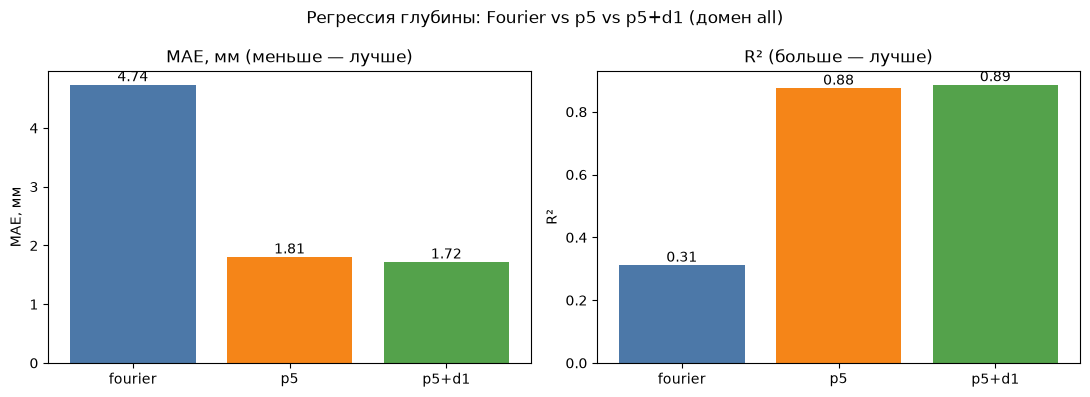

In [20]:
import pandas as pd
rows = [{'feat': n, 'domain': d, **{k: round(v,3) for k,v in md.items()}}
        for n, by in feat_res.items() for d, md in by.items()]
df_feat = pd.DataFrame(rows).set_index(['feat','domain'])
cols = ['mae_mm','rmse_mm','r2','medae_mm','acc_quant']
cols = [c for c in cols if c in df_feat.columns]
print('=== сравнение по типу признаков (все домены) ===')
display(df_feat[cols])

# график: MAE и R2 по признакам (домен all)
allm = {n: feat_res[n]['all'] for n in feat_res}
names = list(allm)
fig, ax = plt.subplots(1, 2, figsize=(11,4))
ax[0].bar(names, [allm[n]['mae_mm'] for n in names], color=['#4C78A8','#F58518','#54A24B'])
ax[0].set_title('MAE, мм (меньше — лучше)'); ax[0].set_ylabel('MAE, мм')
for i,n in enumerate(names): ax[0].text(i, allm[n]['mae_mm'], f"{allm[n]['mae_mm']:.2f}", ha='center', va='bottom')
ax[1].bar(names, [allm[n]['r2'] for n in names], color=['#4C78A8','#F58518','#54A24B'])
ax[1].set_title('R² (больше — лучше)'); ax[1].set_ylabel('R²')
for i,n in enumerate(names): ax[1].text(i, allm[n]['r2'], f"{allm[n]['r2']:.2f}", ha='center', va='bottom')
fig.suptitle('Регрессия глубины: Fourier vs p5 vs p5+d1 (домен all)')
plt.tight_layout(); plt.show()

### Вывод

Сравнение при одинаковых сплите/эпохах: **fourier** (фазограммы низких частот)
по качеству близок к **p5** (обе — «сырые» одноступенчатые признаки), а
**p5+d1** заметно лучше за счёт добавления производной по каналам. То есть
чистые фазовые признаки Фурье конкурентны базовому TSR-полиному, но уступают
TSR с дифференциальным каналом. Числа — в таблице и на графике выше.